#quiz2

step1 : 下載並認識資料庫

In [1]:
import pandas as pd

file_path = "data/UCI_Credit_Card.csv"

df = pd.read_csv(file_path)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
print("資料筆數、欄位數：", df.shape)

資料筆數、欄位數： (30000, 25)


In [3]:
print(df.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [5]:
print(df.isnull().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


Step 2：準備 X 與 Y

In [6]:
# Step 2：準備 X 與 Y

X = df.drop(columns=["ID", "default.payment.next.month"])
y = df["default.payment.next.month"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


Step 3：切分 Training Dataset / Validation Dataset

In [7]:
# Step 3：切分 Training Dataset / Validation Dataset

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (24000, 23)
X_val: (6000, 23)
y_train: (24000,)
y_val: (6000,)


Step 4：Feature Scaling

In [8]:
# Step 4：Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

X_train_scaled shape: (24000, 23)
X_val_scaled shape: (6000, 23)


Step 5：觀察 Feature Scaling 前後

In [9]:
print("Scaling 前：")
print(X_train.iloc[:5, :5])

print("\nScaling 後：")
print(X_train_scaled[:5, :5])

Scaling 前：
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE
22788   160000.0    2          2         2   33
29006   150000.0    2          1         2   34
16950    10000.0    1          2         1   50
22280   220000.0    2          1         2   29
11346   310000.0    2          1         2   32

Scaling 後：
[[-0.05686623  0.80844039  0.18452304  0.85673912 -0.26455769]
 [-0.13408117  0.80844039 -1.07753249  0.85673912 -0.15580369]
 [-1.21509034 -1.23694958  0.18452304 -1.05936739  1.58426024]
 [ 0.40642341  0.80844039 -1.07753249  0.85673912 -0.69957367]
 [ 1.10135788  0.80844039 -1.07753249  0.85673912 -0.37331168]]


In [10]:
# Step 6：建立 MLP

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(23,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Step 7：設定 Loss Function、Optimizer、Learning Rate

In [11]:
# Step 7：設定 Loss Function、Optimizer、Learning Rate

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Step 8：設定 Epoch、Batch Size 並訓練模型

In [12]:
# Step 8：設定 Epoch、Batch Size 並訓練模型

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8092 - loss: 0.4683 - val_accuracy: 0.8127 - val_loss: 0.4579
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8194 - loss: 0.4402 - val_accuracy: 0.8177 - val_loss: 0.4408
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8214 - loss: 0.4325 - val_accuracy: 0.8135 - val_loss: 0.4396
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8223 - loss: 0.4303 - val_accuracy: 0.8188 - val_loss: 0.4364
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8230 - loss: 0.4274 - val_accuracy: 0.8180 - val_loss: 0.4424
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8223 - loss: 0.4259 - val_accuracy: 0.8197 - val_loss: 0.4393
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8227 - loss: 0.4235 - val_accuracy: 0.8213 - val_loss: 0.4384
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8229 - loss: 0.4220 - val_accuracy: 0.

Step 9：繪製 Training Loss / Validation Loss

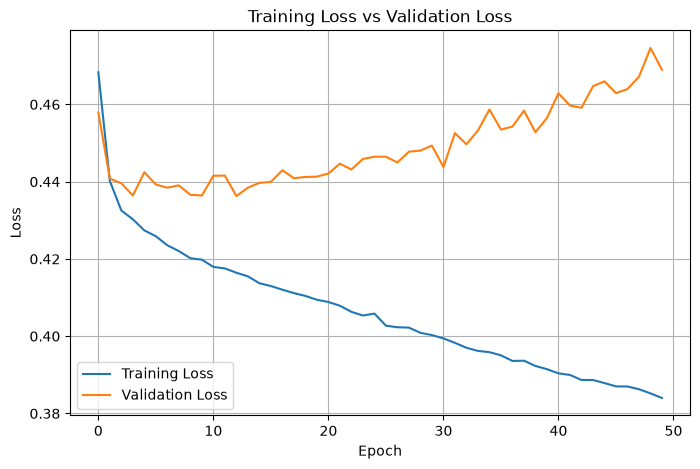

In [13]:
# Step 9：繪製 Training Loss / Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

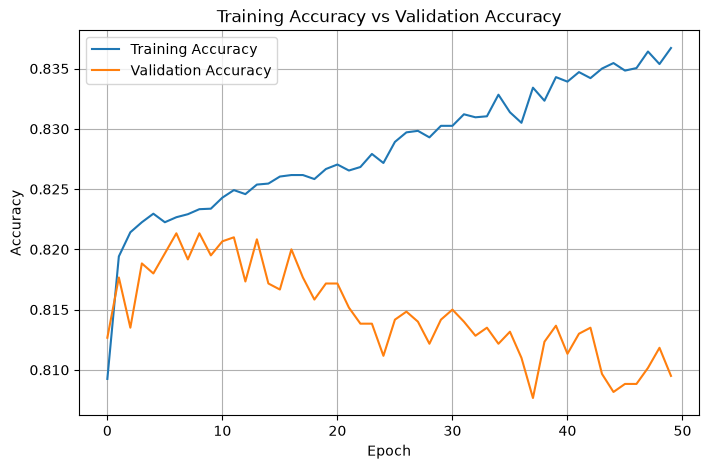

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

Step 10：使用 Validation Dataset 預測

In [15]:
# Step 10：預測 Validation Dataset 的一筆 Sample

sample = X_val_scaled[0].reshape(1, -1)

prediction = model.predict(sample)

print("預測機率：", prediction[0][0])
print("實際答案：", y_val.iloc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
預測機率： 0.08313979
實際答案： 0


Step 11：設定 Threshold 並取得預測結果

In [16]:
# Step 11：Threshold

threshold = 0.5

predicted_class = (prediction[0][0] >= threshold).astype(int)

print("預測機率：", prediction[0][0])
print("Threshold：", threshold)
print("預測結果：", predicted_class)
print("實際答案：", y_val.iloc[0])

預測機率： 0.08313979
Threshold： 0.5
預測結果： 0
實際答案： 0


Step 12：預測全部 Validation Dataset

In [17]:
# Step 12：預測全部 Validation Dataset

y_val_prob = model.predict(X_val_scaled)

threshold = 0.5

y_val_pred = (y_val_prob >= threshold).astype(int)

print("預測機率 shape：", y_val_prob.shape)
print("預測結果 shape：", y_val_pred.shape)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step
預測機率 shape： (6000, 1)
預測結果 shape： (6000, 1)


Step 13：Confusion Matrix + Accuracy / Precision / Recall / F1-Score

In [18]:
# Step 13：Confusion Matrix + 評估指標

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 將預測結果轉成一維
y_val_pred = y_val_pred.ravel()

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

# 評估指標
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("\nEvaluation Metrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Confusion Matrix:
[[4345  328]
 [ 815  512]]

Evaluation Metrics:
Accuracy : 0.8095
Precision: 0.6095238095238096
Recall   : 0.3858327053504145
F1-Score : 0.4725426857406553


Step 14：進階——改善模型-建立加入 Dropout 的 MLP

In [19]:
# Step 14：進階——加入 Dropout 改善模型

from tensorflow.keras.layers import Input, Dense, Dropout

model_dropout = Sequential([
    Input(shape=(23,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_dropout.summary()

model_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Step 15：訓練改善後的模型

In [20]:
history_dropout = model_dropout.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7988 - loss: 0.4982 - val_accuracy: 0.8145 - val_loss: 0.4563
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8115 - loss: 0.4614 - val_accuracy: 0.8165 - val_loss: 0.4450
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8152 - loss: 0.4492 - val_accuracy: 0.8170 - val_loss: 0.4421
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8158 - loss: 0.4461 - val_accuracy: 0.8190 - val_loss: 0.4425
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8175 - loss: 0.4414 - val_accuracy: 0.8202 - val_loss: 0.4389
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8145 - loss: 0.4418 - val_accuracy: 0.8182 - val_loss: 0.4392
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8172 - loss: 0.4385 - val_accuracy: 0.8212 - val_loss: 0.4365
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8163 - loss: 0.4388 - val_accuracy: 0.

Step 15-2：繪製 Dropout 模型的 Loss

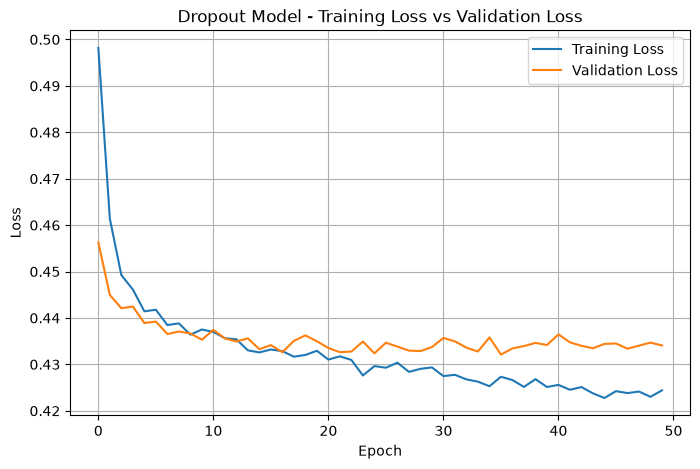

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout Model - Training Loss vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

Step 15-3：繪製 Dropout 模型的 Accuracy

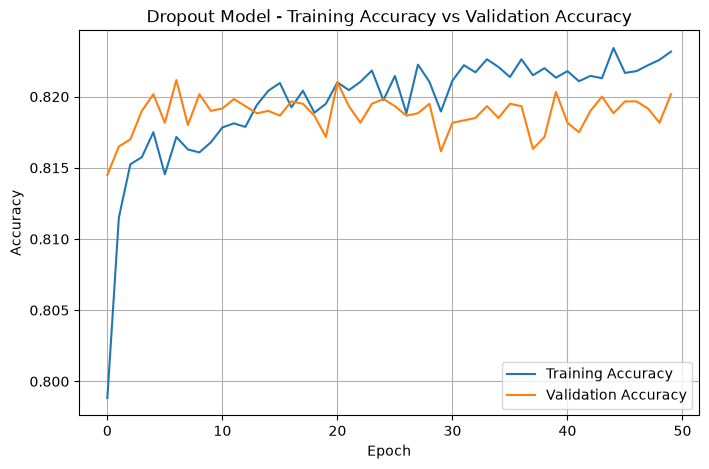

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dropout Model - Training Accuracy vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

Step 16：評估 Dropout 模型

In [23]:
# Step 16：Dropout 模型評估

y_val_prob_dropout = model_dropout.predict(X_val_scaled)

threshold = 0.5

y_val_pred_dropout = (y_val_prob_dropout >= threshold).astype(int)

print("預測機率 shape：", y_val_prob_dropout.shape)
print("預測結果 shape：", y_val_pred_dropout.shape)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
預測機率 shape： (6000, 1)
預測結果 shape： (6000, 1)


In [24]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_val_pred_dropout = y_val_pred_dropout.ravel()

cm_dropout = confusion_matrix(y_val, y_val_pred_dropout)

print("Confusion Matrix:")
print(cm_dropout)

accuracy_dropout = accuracy_score(y_val, y_val_pred_dropout)
precision_dropout = precision_score(y_val, y_val_pred_dropout)
recall_dropout = recall_score(y_val, y_val_pred_dropout)
f1_dropout = f1_score(y_val, y_val_pred_dropout)

print("\nEvaluation Metrics:")
print("Accuracy :", accuracy_dropout)
print("Precision:", precision_dropout)
print("Recall   :", recall_dropout)
print("F1-Score :", f1_dropout)

Confusion Matrix:
[[4474  199]
 [ 880  447]]

Evaluation Metrics:
Accuracy : 0.8201666666666667
Precision: 0.6919504643962848
Recall   : 0.33685003767897514
F1-Score : 0.45311708058793715


Step 18：測試不同 Threshold

In [25]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_val_prob_dropout >= threshold).astype(int).ravel()

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    results.append([
        threshold,
        accuracy,
        precision,
        recall,
        f1
    ])

results = np.array(results)

print("Threshold    Accuracy    Precision    Recall    F1-Score")

for row in results:
    print(
        f"{row[0]:.2f}         "
        f"{row[1]:.4f}      "
        f"{row[2]:.4f}       "
        f"{row[3]:.4f}    "
        f"{row[4]:.4f}"
    )

Threshold    Accuracy    Precision    Recall    F1-Score
0.10         0.4277      0.2695       0.9284    0.4178
0.15         0.5645      0.3178       0.8455    0.4620
0.20         0.6830      0.3839       0.7167    0.5000
0.25         0.7537      0.4568       0.6021    0.5195
0.30         0.7847      0.5123       0.5501    0.5305
0.35         0.8063      0.5735       0.4853    0.5257
0.40         0.8137      0.6205       0.4054    0.4904
0.45         0.8167      0.6523       0.3662    0.4691
0.50         0.8202      0.6920       0.3369    0.4531
0.55         0.8177      0.7033       0.3037    0.4242
0.60         0.8155      0.7292       0.2638    0.3874
0.65         0.8105      0.7610       0.2087    0.3276
0.70         0.7997      0.7778       0.1319    0.2255
0.75         0.7897      0.7778       0.0686    0.1260
0.80         0.7828      0.7609       0.0264    0.0510
0.85         0.7812      1.0000       0.0106    0.0209
0.90         0.7790      1.0000       0.0008    0.0015
0.95    

#quiz3

Step 1：取得 Prediction Score / Probability

In [26]:
y_val_prob = model.predict(X_val_scaled)
y_val_prob = y_val_prob.ravel()

print("Prediction Probability shape:", y_val_prob.shape)
print("前 10 筆 Prediction Probability：")
print(y_val_prob[:10])

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
Prediction Probability shape: (6000,)
前 10 筆 Prediction Probability：
[0.08313979 0.18815675 0.11261424 0.11280206 0.01574867 0.06105174
 0.09698272 0.00596353 0.01777984 0.10879916]


Step 2：計算 ROC Curve

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)

print("FPR shape:", fpr.shape)
print("TPR shape:", tpr.shape)

FPR shape: (1699,)
TPR shape: (1699,)


Step 3：計算 AUC

In [28]:
auc = roc_auc_score(y_val, y_val_prob)

print("AUC:", auc)

AUC: 0.754834769671239


Step 4：畫 ROC Curve

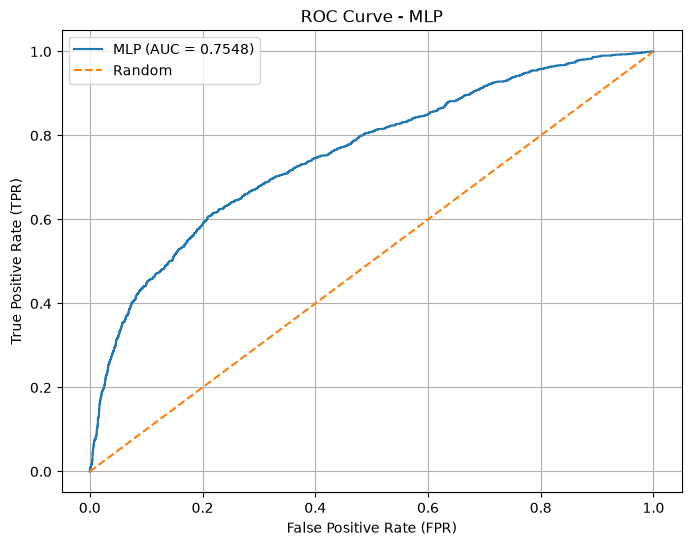

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"MLP (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - MLP")

plt.legend()
plt.grid()
plt.show()

Step 5：說明ROC 與 AUC

ROC Curve

ROC Curve 用來觀察模型在不同分類 Threshold 下，True Positive Rate（TPR）與 False Positive Rate（FPR）之間的關係。其中 X 軸為 FPR，Y 軸為 TPR。

AUC

AUC（Area Under the ROC Curve）代表 ROC Curve 下的面積，可用來衡量模型區分正負樣本的能力。AUC 越接近 1，表示模型區分正負樣本的能力越強。

Step 6：建立 Logistic Regression 模型

In [31]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train);

print("Logistic Regression 訓練完成")

Logistic Regression 訓練完成


Step 7：取得 Logistic Regression 的 Prediction Probability

In [32]:
y_val_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

print("Prediction Probability shape:", y_val_prob_lr.shape)
print("前 10 筆 Prediction Probability：")
print(y_val_prob_lr[:10])

Prediction Probability shape: (6000,)
前 10 筆 Prediction Probability：
[0.10921496 0.11668539 0.22019774 0.09660511 0.02750998 0.20087738
 0.13159178 0.15358892 0.07595841 0.19481887]


Step 8：計算 Logistic Regression 的 ROC 和 AUC

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr, tpr_lr, thresholds_lr = roc_curve(
    y_val,
    y_val_prob_lr
)

auc_lr = roc_auc_score(
    y_val,
    y_val_prob_lr
)

print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.7076355036089734


Step 9：把兩個模型的 ROC 畫在同一張圖

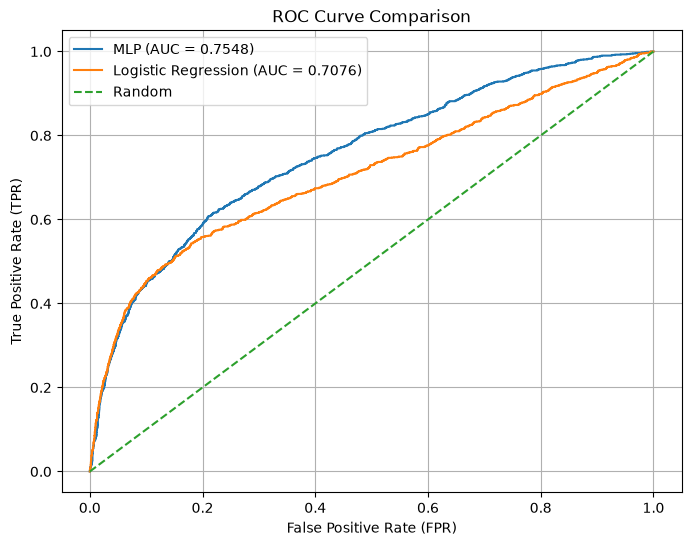

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# MLP
plt.plot(
    fpr,
    tpr,
    label=f"MLP (AUC = {auc:.4f})"
)

# Logistic Regression
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

# Random
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()
plt.show()

Step 10：比較兩個 AUC

In [35]:
print(f"MLP AUC: {auc:.4f}")
print(f"Logistic Regression AUC: {auc_lr:.4f}")

MLP AUC: 0.7548
Logistic Regression AUC: 0.7076


Step 11：比較兩個模型的 ROC Curve 與 AUC

本次使用與 Quiz 2 相同的 Training Dataset 與 Validation Dataset，建立 Logistic Regression 模型，並取得 Validation Dataset 的 Prediction Probability。接著將 MLP 與 Logistic Regression 的 ROC Curve 繪製於同一張圖中。MLP 的 AUC 為 0.7548，Logistic Regression 的 AUC 為 0.7076。在本次 Validation Dataset 上，MLP 的 AUC 較高，因此依據 AUC 結果，MLP 具有較好的正負樣本區分能力。